## Librerias

In [1]:
#!pip install -q kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from getpass import getpass
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Exploración inicial del dataset M5



En este notebook se realiza la primera exploración del dataset M5 Forecasting.

El objetivo es entender:

- Qué archivos componen el dataset.
- Cuántas series de tiempo existen.
- Qué jerarquías tiene la información.
- Qué periodo temporal cubre.
- Cómo se distribuyen las ventas.
- Qué variables externas están disponibles.
- Qué tan adecuado es el dataset para replicar DeepAR.

En este proyecto, cada combinación producto-tienda se tratará como una serie de tiempo individual.

En este notebook se realiza la primera exploración del dataset M5 Forecasting.

El objetivo es entender:

- Qué archivos componen el dataset.
- Cuántas series de tiempo existen.
- Qué jerarquías tiene la información.
- Qué periodo temporal cubre.
- Cómo se distribuyen las ventas.
- Qué variables externas están disponibles.
- Qué tan adecuado es el dataset para replicar DeepAR.

En este proyecto, cada combinación producto-tienda se tratará como una serie de tiempo individual.

In [10]:
!kaggle competitions download -c m5-forecasting-accuracy

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [12]:
DATA_PATH = "/content/"

sales_path = DATA_PATH + "sales_train_validation.csv"
calendar_path = DATA_PATH + "calendar.csv"
prices_path = DATA_PATH + "sell_prices.csv"
submission_path = DATA_PATH + "sample_submission.csv"

In [13]:
sales = pd.read_csv(sales_path)
calendar = pd.read_csv(calendar_path)
prices = pd.read_csv(prices_path)
submission = pd.read_csv(submission_path)

print("sales:", sales.shape)
print("calendar:", calendar.shape)
print("prices:", prices.shape)
print("submission:", submission.shape)

sales: (30490, 1919)
calendar: (1969, 14)
prices: (6841121, 4)
submission: (60980, 29)


Estructura de Ventas

In [14]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [15]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 446.4+ MB


In [16]:
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
date_cols = [col for col in sales.columns if col.startswith("d_")]

print("Columnas identificadoras:", id_cols)
print("Número de columnas de días:", len(date_cols))
print("Primeros días:", date_cols[:5])
print("Últimos días:", date_cols[-5:])

Columnas identificadoras: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
Número de columnas de días: 1913
Primeros días: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Últimos días: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [17]:
n_series = sales["id"].nunique()

print(f"Número de series producto-tienda: {n_series:,}")

Número de series producto-tienda: 30,490


In [18]:
hierarchy_summary = {
    "items": sales["item_id"].nunique(),
    "departments": sales["dept_id"].nunique(),
    "categories": sales["cat_id"].nunique(),
    "stores": sales["store_id"].nunique(),
    "states": sales["state_id"].nunique()
}

hierarchy_summary

{'items': 3049, 'departments': 7, 'categories': 3, 'stores': 10, 'states': 3}

Calendario

In [19]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [20]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [21]:
print("Fecha mínima:", calendar["date"].min())
print("Fecha máxima:", calendar["date"].max())
print("Número de días en calendario:", calendar["d"].nunique())

Fecha mínima: 2011-01-29
Fecha máxima: 2016-06-19
Número de días en calendario: 1969


In [22]:
calendar["date"] = pd.to_datetime(calendar["date"])

calendar[["date", "wm_yr_wk", "weekday", "wday", "month", "year", "d"]].head()

,date,wm_yr_wk,weekday,wday,month,year,d
0,2011-01-29,11101,Saturday,1,1,2011,d_1
1,2011-01-30,11101,Sunday,2,1,2011,d_2
2,2011-01-31,11101,Monday,3,1,2011,d_3
3,2011-02-01,11101,Tuesday,4,2,2011,d_4
4,2011-02-02,11101,Wednesday,5,2,2011,d_5


Precios

In [23]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [24]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [25]:
print("Número de productos en precios:", prices["item_id"].nunique())
print("Número de tiendas en precios:", prices["store_id"].nunique())
print("Número de semanas:", prices["wm_yr_wk"].nunique())

Número de productos en precios: 3049
Número de tiendas en precios: 10
Número de semanas: 282


Ventas totales por dia

In [26]:
daily_sales = sales[date_cols].sum(axis=0).reset_index()
daily_sales.columns = ["d", "sales"]

daily_sales = daily_sales.merge(calendar[["d", "date"]], on="d", how="left")

daily_sales.head()

,d,sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


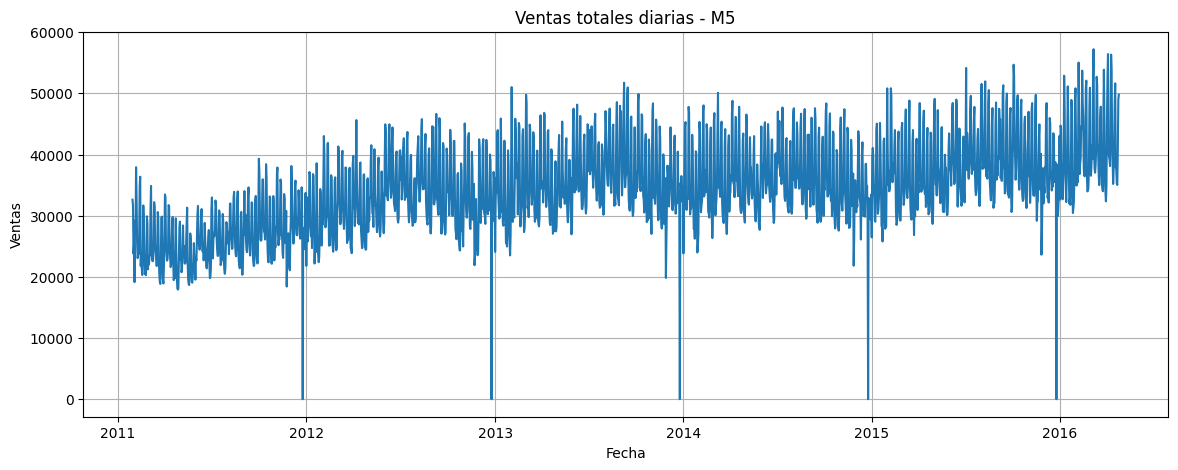

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Ventas totales diarias - M5")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

Ventas por categoria

In [28]:
cat_sales = sales.groupby("cat_id")[date_cols].sum()

cat_sales

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,...,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
cat_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FOODS,23178,22758,17174,18878,14603,22093,20490,27751,24862,18901,16963,17655,17340,19038,25187,26656,16015,17425,15351,14290,16594,20938,20028,16373,14043,13932,13733,15480,19905,20660,15066,16568,16218,17242,17512,23072,24909,17588,16280,16039,16007,18125,22545,22239,17859,17284,15685,15081,16267,20467,...,38547,27978,26276,25601,25491,27897,34734,34710,29086,27703,24605,23502,26455,29999,31758,24910,24242,23262,22874,30906,37135,32236,23285,22191,21017,22127,28627,34284,37633,27025,27243,27238,25655,29449,38334,36446,29091,27424,23888,25456,28682,32007,34497,26151,24948,23632,23317,26704,31927,32654
HOBBIES,3764,3357,2682,2669,1814,3220,2944,3986,2899,2615,2547,2457,2700,2822,3699,3417,2233,2554,2170,2049,2284,4142,2978,2735,2459,2758,2559,2675,4088,2118,1771,1833,1675,1855,1653,2096,3795,2687,2519,2955,2686,2688,3630,3282,2500,2522,2736,2434,2687,3702,...,4879,3356,3240,3203,3787,3333,4810,4229,3593,3552,3621,3218,3794,4735,4006,3342,3140,3422,3352,4230,4476,3643,3555,3446,3333,3421,4790,4863,4903,3661,3477,3379,3443,4066,4739,4525,3716,3384,3557,3786,3786,4634,4820,3323,3787,3472,3353,4085,4787,4683
HOUSEHOLD,5689,5634,3927,3865,2729,3898,4576,6195,4975,4056,3561,3546,3716,4585,5947,6307,3556,4091,3922,3979,4843,6609,6277,4858,3999,4067,3985,4374,5915,5929,4403,4471,4153,4378,4407,6034,6172,4287,3953,3566,3933,4759,6050,5896,4576,4215,4344,4264,4901,6430,...,13792,9228,8211,8228,8989,9657,13167,12482,9356,8862,8380,8289,9403,11447,12061,9108,8093,8102,7777,10475,12252,10481,9201,8220,8009,9133,12119,13525,13889,9732,8963,8517,9018,9705,13267,12885,9620,8261,7748,8287,9321,11721,12323,8585,8835,8239,8363,9728,12248,12458


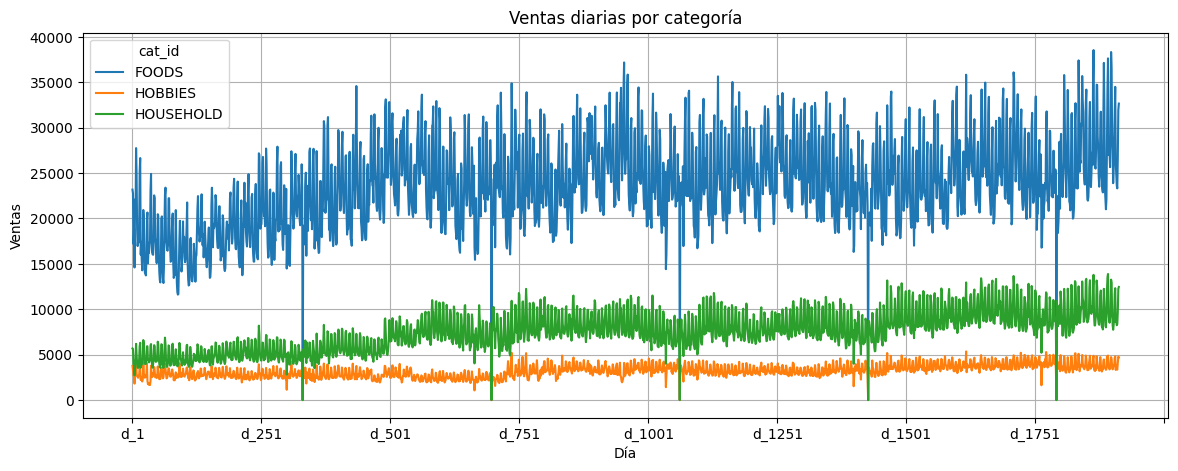

In [29]:
cat_sales.T.plot(figsize=(14, 5))
plt.title("Ventas diarias por categoría")
plt.xlabel("Día")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

Ventas por Estado

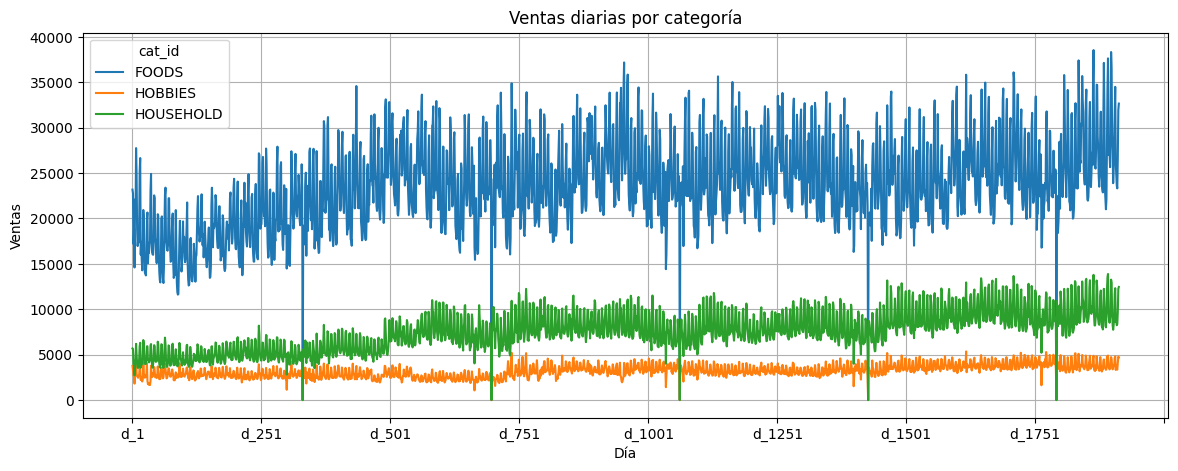

In [30]:
cat_sales.T.plot(figsize=(14, 5))
plt.title("Ventas diarias por categoría")
plt.xlabel("Día")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

In [31]:
sales["total_sales"] = sales[date_cols].sum(axis=1)
sales["mean_sales"] = sales[date_cols].mean(axis=1)

sales[["total_sales", "mean_sales"]].describe()

,total_sales,mean_sales
count,30490.000000,30490.000000
mean,2154.654280,1.126322
std,5217.226438,2.727249
min,10.000000,0.005227
25%,355.000000,0.185572
50%,848.000000,0.443283
75%,2031.750000,1.062075
max,250502.000000,130.947203


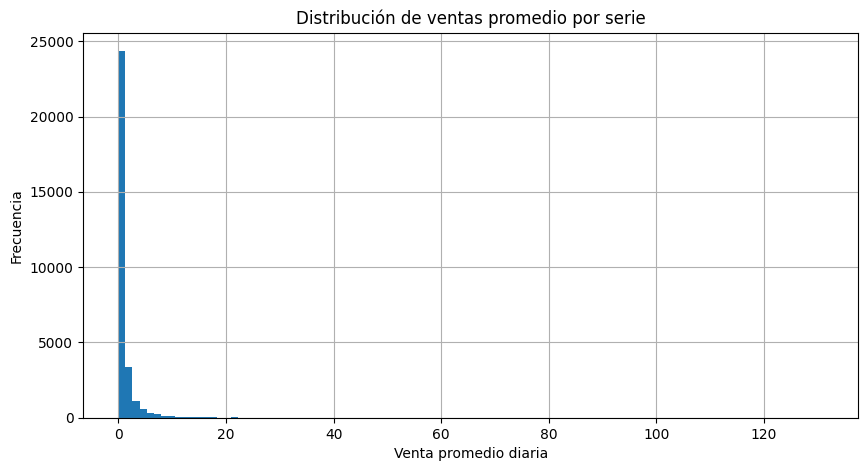

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(sales["mean_sales"], bins=100)
plt.title("Distribución de ventas promedio por serie")
plt.xlabel("Venta promedio diaria")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

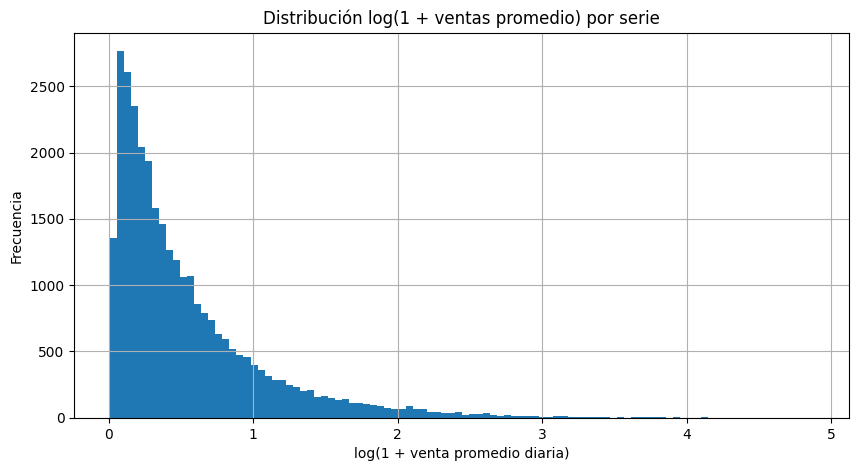

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(sales["mean_sales"]), bins=100)
plt.title("Distribución log(1 + ventas promedio) por serie")
plt.xlabel("log(1 + venta promedio diaria)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

In [34]:
zero_ratio = (sales[date_cols] == 0).mean(axis=1)

sales["zero_ratio"] = zero_ratio

sales["zero_ratio"].describe()

,zero_ratio
count,30490.000000
mean,0.681963
std,0.223773
min,0.001568
25%,0.536853
50%,0.735494
75%,0.867224
max,0.996341


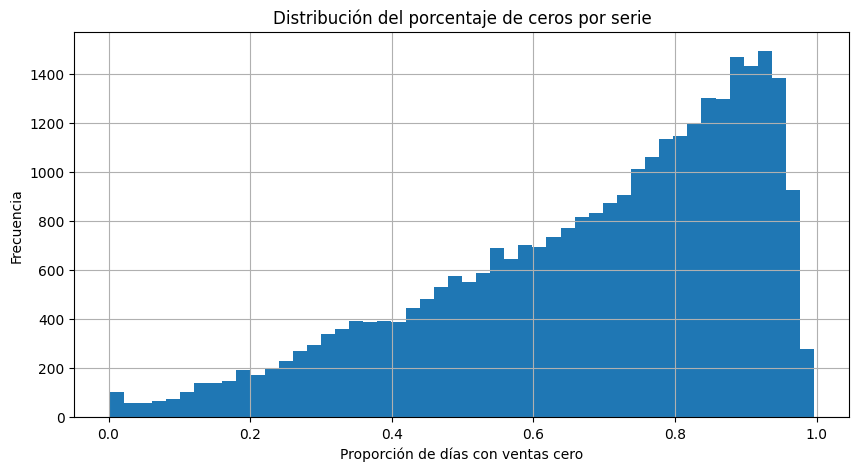

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(sales["zero_ratio"], bins=50)
plt.title("Distribución del porcentaje de ceros por serie")
plt.xlabel("Proporción de días con ventas cero")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

Series con mas ventas

In [36]:
top_series = sales.sort_values("total_sales", ascending=False).head(5)

top_series[id_cols + ["total_sales", "mean_sales", "zero_ratio"]]

,id,item_id,dept_id,cat_id,store_id,state_id,total_sales,mean_sales,zero_ratio
8412,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,250502,130.947203,0.187663
18055,FOODS_3_586_TX_2_validation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,192835,100.802405,0.004182
21104,FOODS_3_586_TX_3_validation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,150122,78.474647,0.003659
8908,FOODS_3_586_CA_3_validation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,134386,70.248824,0.002614
2314,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,127203,66.493988,0.245165


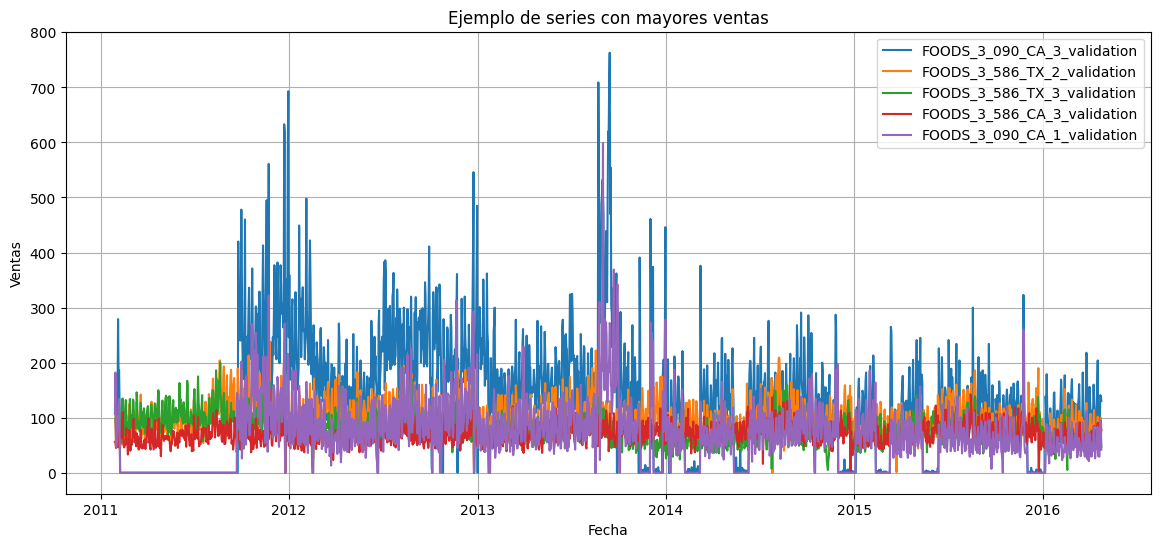

In [37]:
sample_ids = top_series["id"].tolist()

plt.figure(figsize=(14, 6))

for sid in sample_ids:
    row = sales.loc[sales["id"] == sid, date_cols].values.flatten()
    plt.plot(calendar.loc[calendar["d"].isin(date_cols), "date"], row, label=sid)

plt.title("Ejemplo de series con mayores ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

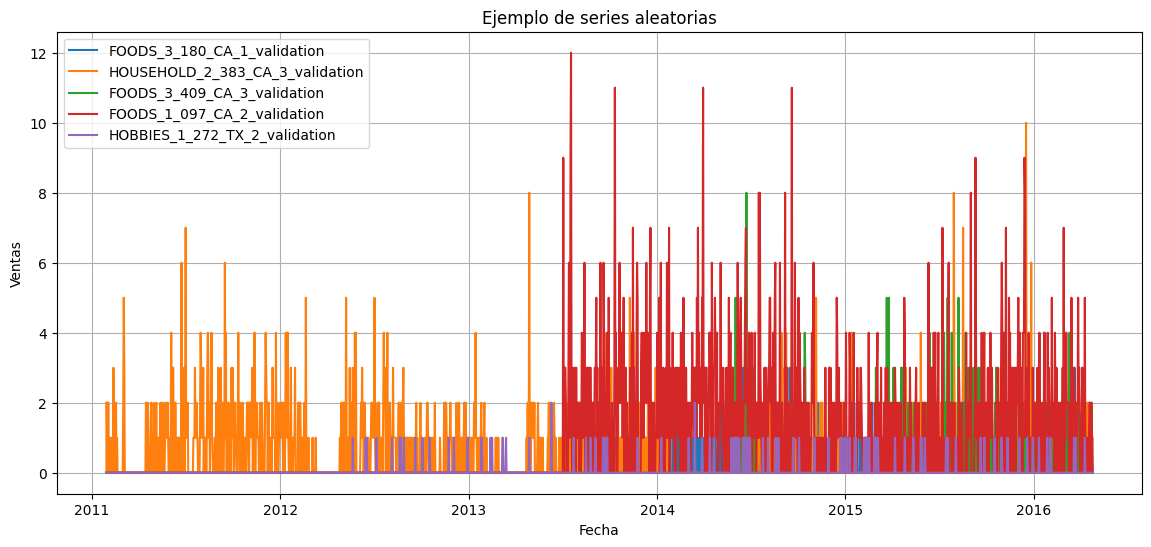

In [38]:
random_series = sales.sample(5, random_state=42)

plt.figure(figsize=(14, 6))

for _, row in random_series.iterrows():
    plt.plot(calendar.loc[calendar["d"].isin(date_cols), "date"], row[date_cols].values, label=row["id"])

plt.title("Ejemplo de series aleatorias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()